In [7]:
#PCA on diabetes dataset
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

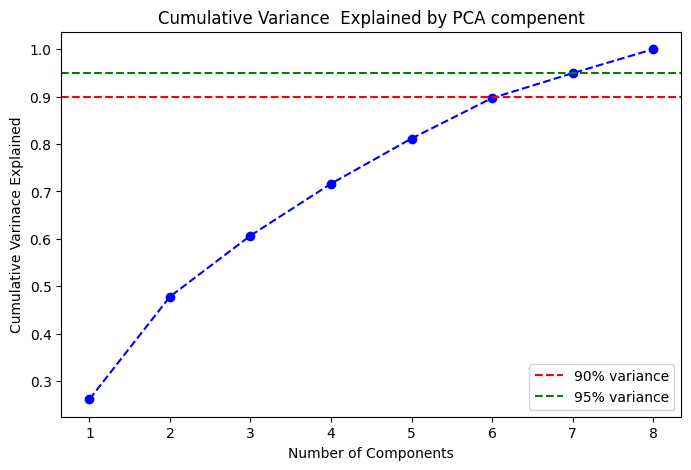

In [16]:
df=pd.read_csv('diabetes.csv')
numerical_cols=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

#Handle missing values for numerical columns
numerical_data=df[numerical_cols]
imputer_num=SimpleImputer(strategy='mean')
numerical_data=imputer_num.fit_transform(numerical_data)
numerical_df=pd.DataFrame(numerical_data,columns=numerical_cols)

#Standardize the data
scaler=StandardScaler()
data_scaled=scaler.fit_transform(numerical_df)

#Apply PCA
pca=PCA() #Keep all components
X_pca=pca.fit_transform(data_scaled)

#Variance captured by each component
explained_variance=pca.explained_variance_ratio_
cumulative_variance=np.cumsum(explained_variance)

#Plot cummulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title("Cumulative Variance  Explained by PCA compenent")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Varinace Explained")
plt.axhline(y=0.9,color='r',linestyle="--",label="90% variance")
plt.axhline(y=0.95,color='g',linestyle="--",label="95% variance")
plt.legend()
plt.show()


In [18]:
#Dispaly PCA results
print("Expalined Variance Ratio(for each PC):")
print(explained_variance)
print("\nCumulative Variance:")
print(cumulative_variance)

Expalined Variance Ratio(for each PC):
[0.26179749 0.21640127 0.12870373 0.10944113 0.09529305 0.08532855
 0.05247702 0.05055776]

Cumulative Variance:
[0.26179749 0.47819876 0.60690249 0.71634362 0.81163667 0.89696522
 0.94944224 1.        ]


In [20]:
#show composition (loadings ) of each Principle Component
loadings=pd.DataFrame(pca.components_,columns=numerical_cols,index=[f"PC{i+1}" for i in range(len(numerical_cols))])
print("\nCompositions of each Principle Component :")
print(loadings)


Compositions of each Principle Component :
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
PC1     0.128432  0.393083       0.360003       0.439824  0.435026  0.451941   
PC2     0.593786  0.174029       0.183892      -0.331965 -0.250781 -0.100960   
PC3     0.013087 -0.467923       0.535494       0.237674 -0.336709  0.361865   
PC4     0.080691 -0.404329       0.055986       0.037976 -0.349944  0.053646   
PC5     0.475606 -0.466328      -0.327953       0.487862  0.346935 -0.253204   
PC6     0.193598  0.094162      -0.634116       0.009589 -0.270651  0.685372   
PC7    -0.588790 -0.060153      -0.192118       0.282213 -0.132010 -0.035366   
PC8     0.117841  0.450355      -0.011296       0.566284 -0.548621 -0.341518   

     DiabetesPedigreeFunction       Age  
PC1                  0.270611  0.198027  
PC2                 -0.122069  0.620589  
PC3                 -0.433189 -0.075248  
PC4                  0.833680  0.071201  
PC5                 -0.11

In [26]:
#select first three principle components
X_selected=X_pca[:,:3]
#prepare the target varible
y=df["Outcome"]
#split data into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(X_selected,y,test_size=0.2,random_state=42)

In [29]:
#train a Logistic Regerssion model
log_reg=LogisticRegression(random_state=42)
log_reg.fit(X_train,y_train)
y_pred=log_reg.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
conf_matrix=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
print(f"Accuracy:{accuracy:.2f}")
print(conf_matrix)
print(report)

Accuracy:0.73
[[82 17]
 [25 30]]
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.64      0.55      0.59        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154

